# MVP de Machine Learning - Classificação da Qualidade de Vinhos Tintos

**Aluna:** Ana Beatriz Maciel de Almeida - 221006478  
**Disciplina:** Sistemas de Suporte à Decisão  
**Tema:** Análise descritiva e preditiva da qualidade de vinhos

---

## 1. Definição do problema

Este MVP investiga se medidas físico-químicas conseguem distinguir vinhos tintos com **alta qualidade** dos demais. A qualidade original é uma nota sensorial de 0 a 10. Para criar um problema de classificação binária, serão considerados:

- **Classe 1 — Alta qualidade:** nota igual ou superior a 7;
- **Classe 0 — Demais vinhos:** nota inferior a 7.


### Pergunta de pesquisa

> É possível prever se um vinho tinto será classificado como de alta qualidade utilizando apenas suas características físico-químicas?

### Hipótese

As características físico-químicas apresentam poder preditivo superior a um classificador ingênuo que sempre escolhe a classe majoritária.

## 2. Fonte e descrição dos dados

Será utilizada a base pública **Wine Quality**, disponibilizada pelo [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality). O recorte contém amostras de vinhos tintos portugueses do tipo *Vinho Verde*.

O conjunto original possui 1.599 observações, 11 variáveis físico-químicas e a nota sensorial `quality`.

**Referência:** Cortez, P.; Cerdeira, A.; Almeida, F.; Matos, T.; Reis, J. (2009). *Wine Quality*. UCI Machine Learning Repository. DOI: [10.24432/C56S3T](https://doi.org/10.24432/C56S3T).

## 3. Configuração do ambiente

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    make_scorer,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


## 4. Carregamento e compreensão inicial

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
dados_originais = pd.read_csv(url, sep=";")

print(f"Dimensão da base original: {dados_originais.shape[0]} linhas e {dados_originais.shape[1]} colunas")
display(dados_originais.head())

Dimensão da base original: 1599 linhas e 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Dicionário das variáveis

| Variável | Descrição |
|---|---|
| `fixed acidity` | Acidez fixa |
| `volatile acidity` | Acidez volátil |
| `citric acid` | Ácido cítrico |
| `residual sugar` | Açúcar residual |
| `chlorides` | Cloretos |
| `free sulfur dioxide` | Dióxido de enxofre livre |
| `total sulfur dioxide` | Dióxido de enxofre total |
| `density` | Densidade |
| `pH` | Potencial hidrogeniônico |
| `sulphates` | Sulfatos |
| `alcohol` | Teor alcoólico |
| `quality` | Nota sensorial de qualidade |

### 4.1 Verificação da qualidade dos dados

In [ ]:
auditoria = pd.DataFrame({
    "tipo": dados_originais.dtypes.astype(str),
    "valores_ausentes": dados_originais.isna().sum(),
    "valores_unicos": dados_originais.nunique(),
})

duplicados = dados_originais.duplicated().sum()

print(f"Total de valores ausentes: {dados_originais.isna().sum().sum()}")
print(f"Linhas exatamente duplicadas: {duplicados}")
display(auditoria)

Total de valores ausentes: 0
Linhas exatamente duplicadas: 240


,tipo,valores_ausentes,valores_unicos
fixed acidity,float64,0,96
volatile acidity,float64,0,143
citric acid,float64,0,80
residual sugar,float64,0,91
chlorides,float64,0,153
free sulfur dioxide,float64,0,60
total sulfur dioxide,float64,0,144
density,float64,0,436
pH,float64,0,89
sulphates,float64,0,96


Como a base não possui identificador de lote, não é possível verificar se registros idênticos correspondem a repetições legítimas. Para reduzir o risco de uma mesma combinação aparecer simultaneamente no treino e no teste, as duplicatas exatas serão removidas. Essa escolha será registrada como uma limitação do estudo.

In [ ]:
dados = dados_originais.drop_duplicates().reset_index(drop=True)

print(f"Linhas antes da remoção: {len(dados_originais)}")
print(f"Linhas após a remoção:  {len(dados)}")
print(f"Linhas removidas:       {len(dados_originais) - len(dados)}")

Linhas antes da remoção: 1599
Linhas após a remoção:  1359
Linhas removidas:       240


## 5. Análise descritiva

### 5.1 Estatísticas gerais

In [ ]:
display(dados.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.311,1.737,4.600,7.100,7.900,9.200,15.900
volatile acidity,1359.0,0.529,0.183,0.120,0.390,0.520,0.640,1.580
citric acid,1359.0,0.272,0.196,0.000,0.090,0.260,0.430,1.000
residual sugar,1359.0,2.523,1.352,0.900,1.900,2.200,2.600,15.500
chlorides,1359.0,0.088,0.049,0.012,0.070,0.079,0.091,0.611
free sulfur dioxide,1359.0,15.893,10.447,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1359.0,46.826,33.409,6.000,22.000,38.000,63.000,289.000
density,1359.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1359.0,3.310,0.155,2.740,3.210,3.310,3.400,4.010
sulphates,1359.0,0.659,0.171,0.330,0.550,0.620,0.730,2.000


### 5.2 Distribuição da nota de qualidade

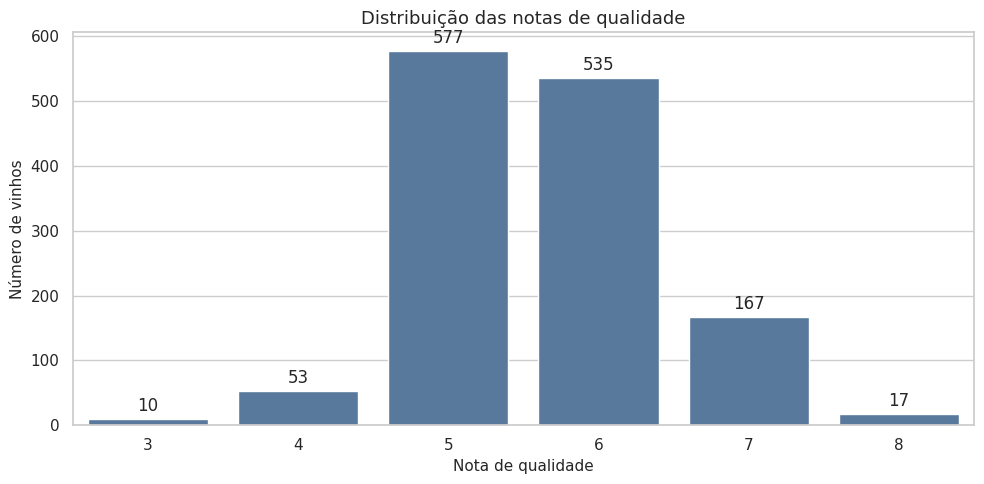

,quantidade
quality,
3,10
4,53
5,577
6,535
7,167
8,17


In [ ]:
ordem_notas = sorted(dados["quality"].unique())
contagem_notas = dados["quality"].value_counts().sort_index()

ax = sns.countplot(data=dados, x="quality", order=ordem_notas, color="#4C78A8")
ax.set_title("Distribuição das notas de qualidade")
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Número de vinhos")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

display(contagem_notas.rename("quantidade").to_frame())

As notas observadas concentram-se nas categorias intermediárias, enquanto notas muito baixas ou muito altas são raras. Isso antecipa um desafio importante: a classe de alta qualidade será minoritária.

### 5.3 Construção e distribuição da variável-alvo

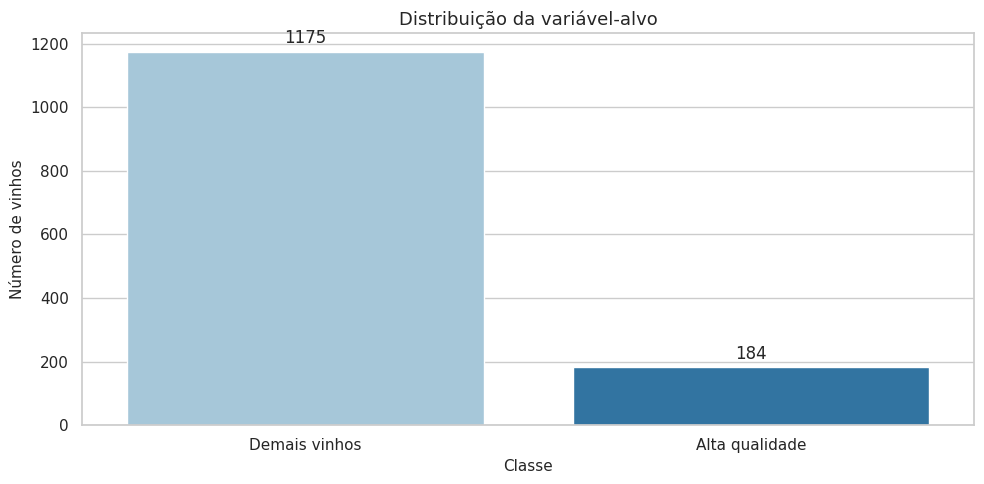

,quantidade,percentual
alta_qualidade,,
Demais vinhos,1175,86.5
Alta qualidade,184,13.5


In [ ]:
dados["alta_qualidade"] = (dados["quality"] >= 7).astype(int)

distribuicao_alvo = (
    dados["alta_qualidade"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Demais vinhos", 1: "Alta qualidade"})
    .to_frame("quantidade")
)
distribuicao_alvo["percentual"] = (
    distribuicao_alvo["quantidade"] / distribuicao_alvo["quantidade"].sum() * 100
).round(1)

ax = sns.countplot(
    data=dados,
    x="alta_qualidade",
    order=[0, 1],
    palette=["#9ECAE1", "#1F77B4"],
)
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de vinhos")
ax.set_xticklabels(["Demais vinhos", "Alta qualidade"])

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

display(distribuicao_alvo)

O desbalanceamento torna a **acurácia isolada inadequada**. Um modelo que sempre previsse “demais vinhos” obteria acurácia elevada, mas jamais identificaria um vinho de alta qualidade. Por isso, a avaliação considerará especialmente precisão, recall, F1-score, acurácia balanceada e as áreas sob as curvas ROC e precisão-recall.

### 5.4 Relação entre as variáveis e a nota original

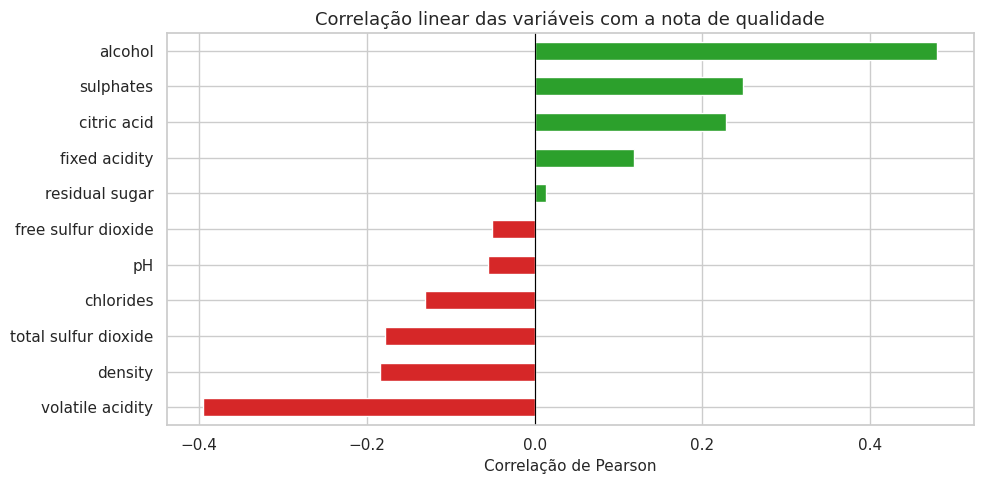

,correlacao_com_quality
volatile acidity,-0.395
density,-0.184
total sulfur dioxide,-0.178
chlorides,-0.131
pH,-0.055
free sulfur dioxide,-0.050
residual sugar,0.014
fixed acidity,0.119
citric acid,0.228
sulphates,0.249


In [ ]:
correlacao_qualidade = (
    dados.drop(columns="alta_qualidade")
    .corr(numeric_only=True)["quality"]
    .drop("quality")
    .sort_values()
)

cores = ["#D62728" if valor < 0 else "#2CA02C" for valor in correlacao_qualidade]

ax = correlacao_qualidade.plot(kind="barh", color=cores)
ax.set_title("Correlação linear das variáveis com a nota de qualidade")
ax.set_xlabel("Correlação de Pearson")
ax.set_ylabel("")
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

display(correlacao_qualidade.rename("correlacao_com_quality").to_frame().round(3))

Correlação mede associação linear e não causalidade. Valores próximos de zero também não provam ausência de relação, pois podem existir padrões não lineares ou interações entre variáveis.

### 5.5 Comparação das principais características entre as classes

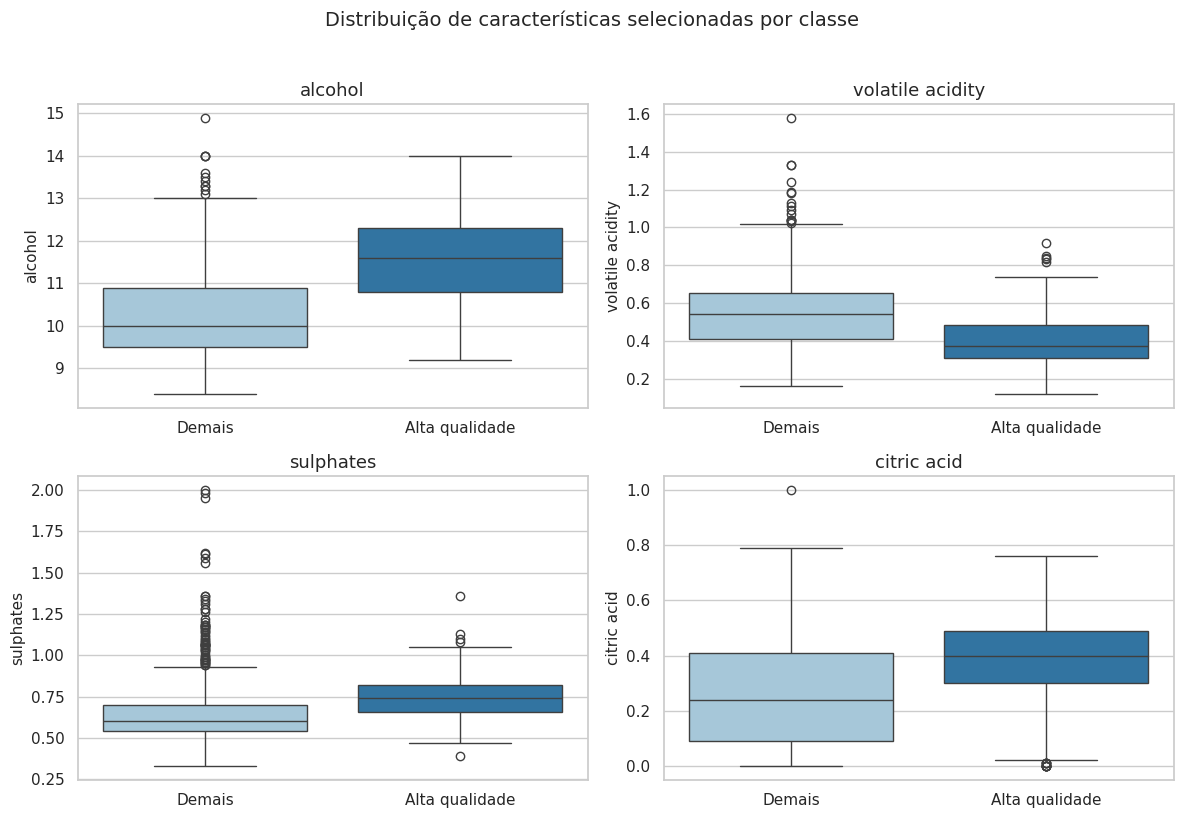

In [ ]:
variaveis_destaque = ["alcohol", "volatile acidity", "sulphates", "citric acid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, variavel in zip(axes, variaveis_destaque):
    sns.boxplot(
        data=dados,
        x="alta_qualidade",
        y=variavel,
        order=[0, 1],
        palette=["#9ECAE1", "#1F77B4"],
        ax=ax,
    )
    ax.set_title(variavel)
    ax.set_xlabel("")
    ax.set_xticklabels(["Demais", "Alta qualidade"])

fig.suptitle("Distribuição de características selecionadas por classe", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
comparacao_classes = (
    dados.groupby("alta_qualidade")[variaveis_destaque]
    .median()
    .rename(index={0: "Demais vinhos", 1: "Alta qualidade"})
    .T
)
comparacao_classes["diferença percentual"] = (
    (comparacao_classes["Alta qualidade"] / comparacao_classes["Demais vinhos"] - 1) * 100
).round(1)

display(comparacao_classes.round(3))

alta_qualidade,Demais vinhos,Alta qualidade,diferença percentual
alcohol,10.00,11.60,16.0
volatile acidity,0.54,0.37,-31.5
sulphates,0.60,0.74,23.3
citric acid,0.24,0.40,66.7


### 5.6 Matriz de correlação

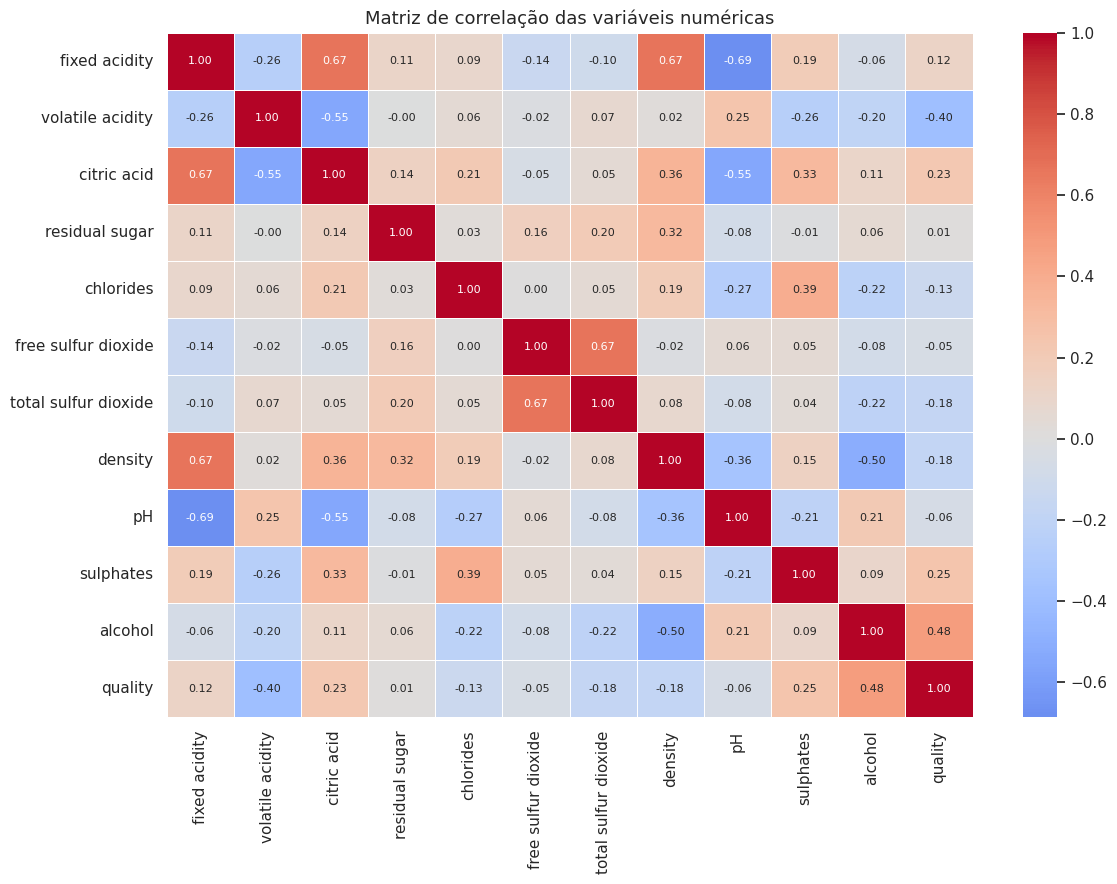

In [ ]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    dados.drop(columns="alta_qualidade").corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    annot_kws={"size": 8},
)
plt.title("Matriz de correlação das variáveis numéricas")
plt.tight_layout()
plt.show()

### Síntese da análise descritiva

- A base não possui valores ausentes, mas contém observações exatamente duplicadas.
- As notas estão concentradas em 5 e 6; vinhos com nota 7 ou 8 representam a minoria.
- O teor alcoólico apresenta associação positiva com a nota, enquanto a acidez volátil apresenta associação negativa.
- Sulfatos e ácido cítrico também mostram diferenças entre as classes, embora menores.
- Algumas variáveis são correlacionadas entre si, o que reforça a utilidade de comparar um modelo linear com outro capaz de representar relações não lineares.

## 6. Preparação para a modelagem preditiva

In [ ]:
X = dados.drop(columns=["quality", "alta_qualidade"])
y = dados["alta_qualidade"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

resumo_divisao = pd.DataFrame({
    "conjunto": ["Treino", "Teste"],
    "observações": [len(X_treino), len(X_teste)],
    "% alta qualidade": [y_treino.mean() * 100, y_teste.mean() * 100],
})

display(resumo_divisao.round(2))

,conjunto,observações,% alta qualidade
0,Treino,1019,13.54
1,Teste,340,13.53


A divisão é estratificada para preservar a proporção da classe minoritária. A padronização será aplicada somente dentro do pipeline da Regressão Logística, evitando vazamento de informações do conjunto de teste.

## 7. Modelos avaliados

Serão comparadas três abordagens:

1. **Dummy Classifier:** baseline que sempre prevê a classe majoritária;
2. **Regressão Logística:** modelo linear, simples e interpretável;
3. **Random Forest:** modelo baseado em múltiplas árvores, capaz de capturar relações não lineares e interações.

Os dois modelos de machine learning recebem tratamento para o desbalanceamento das classes. Os parâmetros foram mantidos intencionalmente simples, coerentes com o escopo de um MVP.

In [ ]:
modelos = {
    "Baseline majoritário": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": Pipeline(steps=[
        ("padronizacao", StandardScaler()),
        ("modelo", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

print("Modelos definidos:")
for nome in modelos:
    print(f"- {nome}")

Modelos definidos:
- Baseline majoritário
- Regressão Logística
- Random Forest


### 7.1 Validação cruzada no conjunto de treino

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

metricas_cv = {
    "Acurácia balanceada": "balanced_accuracy",
    "Precisão": make_scorer(precision_score, zero_division=0),
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
}

linhas_cv = []

for nome, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_treino,
        y_treino,
        cv=cv,
        scoring=metricas_cv,
        n_jobs=1,
    )
    linha = {"Modelo": nome}
    for metrica in metricas_cv:
        chave = f"test_{metrica}"
        linha[metrica] = scores[chave].mean()
        linha[f"{metrica} (desvio)"] = scores[chave].std()
    linhas_cv.append(linha)

resultados_cv = pd.DataFrame(linhas_cv).set_index("Modelo")
colunas_medias = list(metricas_cv.keys())

print("Média das métricas em 5 divisões estratificadas do treino:")
display(resultados_cv[colunas_medias].round(3))

Média das métricas em 5 divisões estratificadas do treino:


,Acurácia balanceada,Precisão,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
Baseline majoritário,0.500,0.000,0.000,0.000,0.500,0.135
Regressão Logística,0.807,0.385,0.820,0.523,0.876,0.510
Random Forest,0.739,0.517,0.559,0.535,0.883,0.593


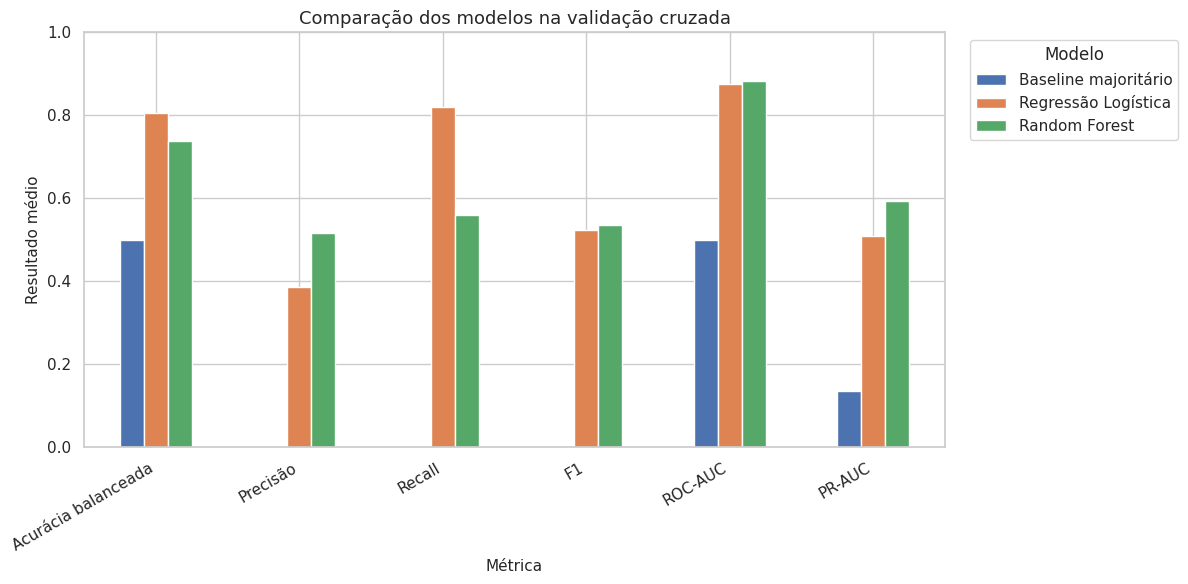

In [ ]:
resultados_cv[colunas_medias].T.plot(kind="bar", figsize=(12, 6))
plt.title("Comparação dos modelos na validação cruzada")
plt.xlabel("Métrica")
plt.ylabel("Resultado médio")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8. Avaliação final no conjunto de teste

In [ ]:
linhas_teste = []
previsoes = {}
probabilidades = {}

for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_previsto = modelo.predict(X_teste)
    y_probabilidade = modelo.predict_proba(X_teste)[:, 1]

    previsoes[nome] = y_previsto
    probabilidades[nome] = y_probabilidade

    linhas_teste.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_teste, y_previsto),
        "Acurácia balanceada": balanced_accuracy_score(y_teste, y_previsto),
        "Precisão": precision_score(y_teste, y_previsto, zero_division=0),
        "Recall": recall_score(y_teste, y_previsto),
        "F1": f1_score(y_teste, y_previsto),
        "ROC-AUC": roc_auc_score(y_teste, y_probabilidade),
        "PR-AUC": average_precision_score(y_teste, y_probabilidade),
    })

resultados_teste = (
    pd.DataFrame(linhas_teste)
    .set_index("Modelo")
    .sort_values("F1", ascending=False)
)

display(resultados_teste.round(3))

,Acurácia,Acurácia balanceada,Precisão,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,,
Random Forest,0.856,0.742,0.474,0.587,0.524,0.874,0.516
Regressão Logística,0.776,0.816,0.364,0.870,0.513,0.876,0.529
Baseline majoritário,0.865,0.500,0.000,0.000,0.000,0.500,0.135


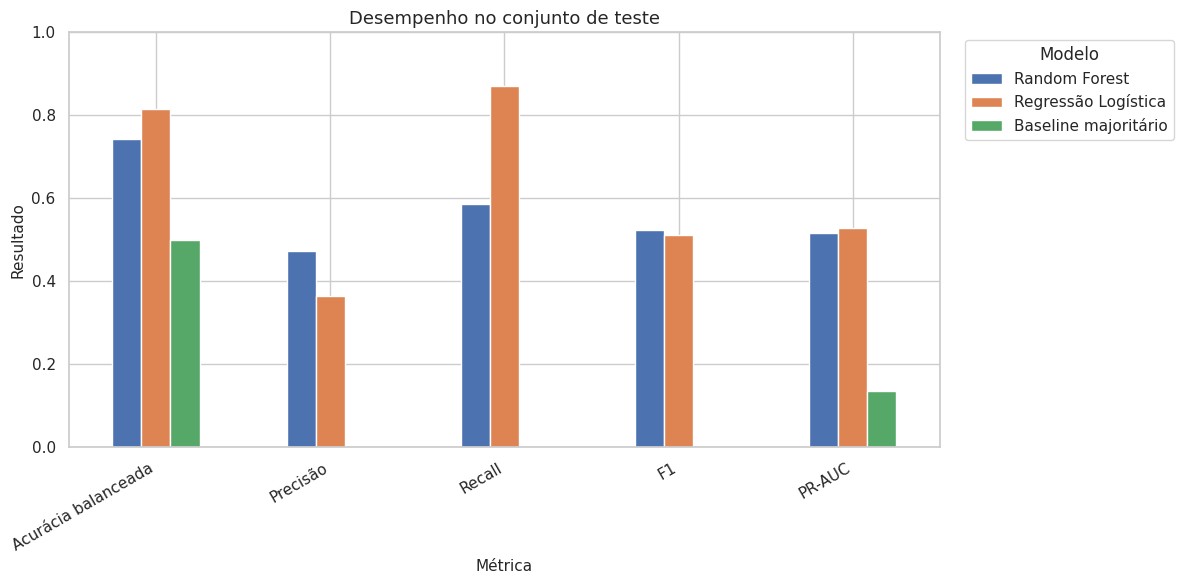

In [ ]:
metricas_grafico = ["Acurácia balanceada", "Precisão", "Recall", "F1", "PR-AUC"]

resultados_teste[metricas_grafico].T.plot(kind="bar", figsize=(12, 6))
plt.title("Desempenho no conjunto de teste")
plt.xlabel("Métrica")
plt.ylabel("Resultado")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.1 Matrizes de confusão

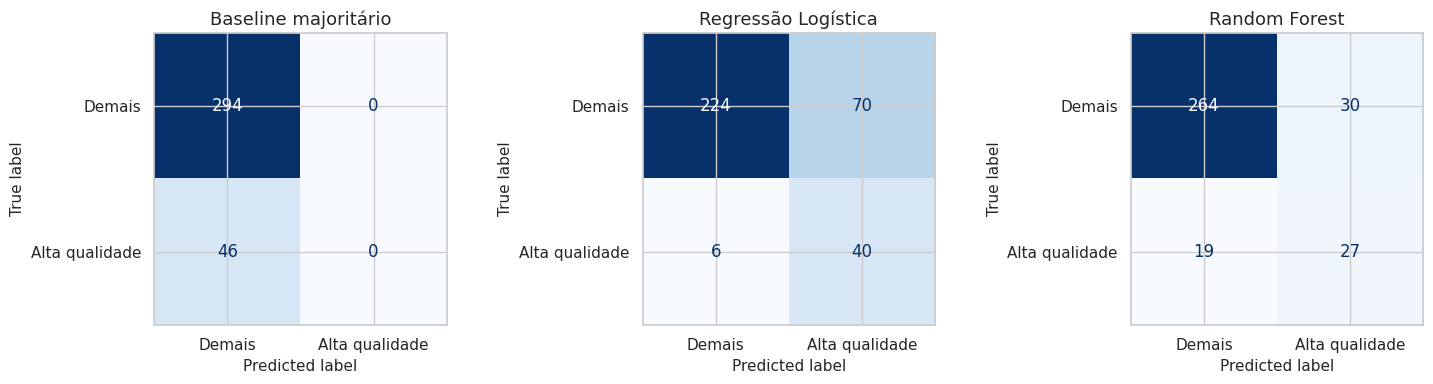

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, y_previsto) in zip(axes, previsoes.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_teste, y_previsto),
        display_labels=["Demais", "Alta qualidade"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

### 8.2 Curvas ROC e precisão-recall

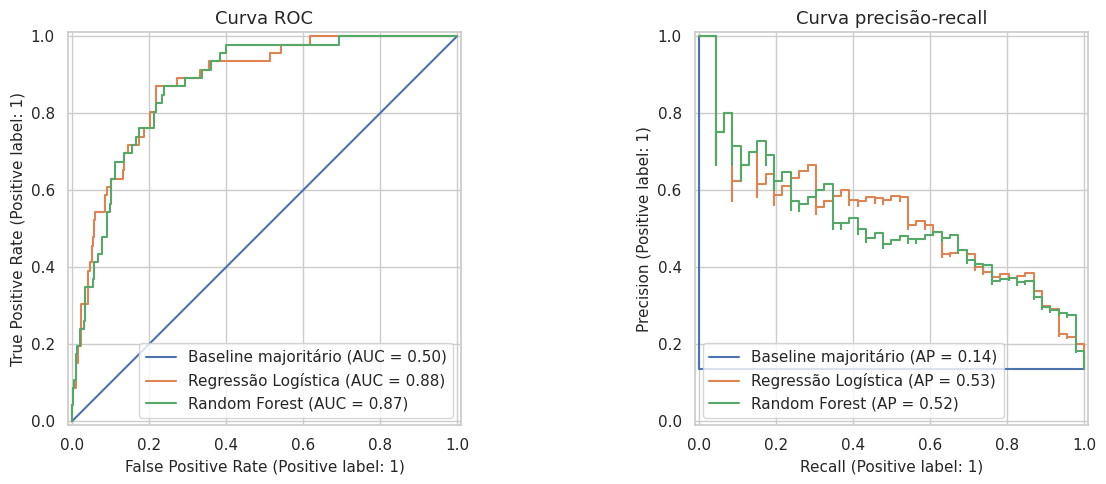

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nome in modelos:
    RocCurveDisplay.from_predictions(
        y_teste,
        probabilidades[nome],
        name=nome,
        ax=axes[0],
    )
    PrecisionRecallDisplay.from_predictions(
        y_teste,
        probabilidades[nome],
        name=nome,
        ax=axes[1],
    )

axes[0].set_title("Curva ROC")
axes[1].set_title("Curva precisão-recall")
plt.tight_layout()
plt.show()

A curva precisão-recall é especialmente informativa neste problema porque evidencia o desempenho sobre a classe minoritária. O baseline estabelece o resultado que seria obtido sem aprender padrões relevantes nos dados.

## 9. Interpretação dos modelos

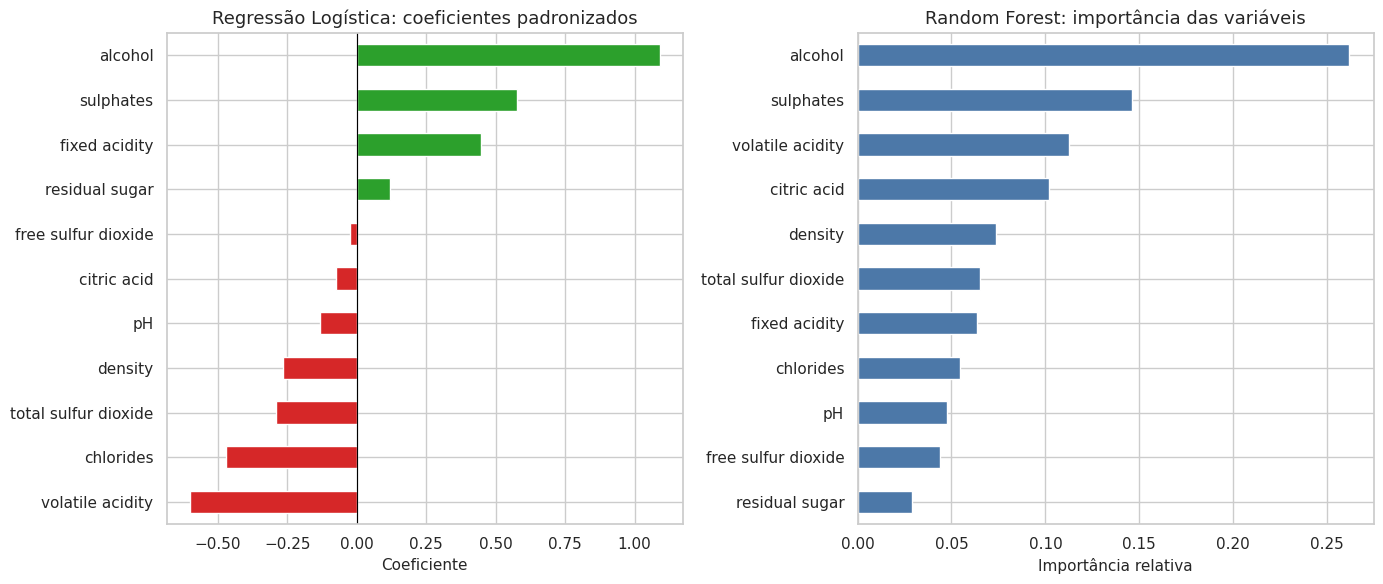

,coeficiente,importancia
alcohol,1.089,0.262
sulphates,0.578,0.146
volatile acidity,-0.599,0.113
citric acid,-0.076,0.102
density,-0.265,0.074
total sulfur dioxide,-0.289,0.065
fixed acidity,0.448,0.063
chlorides,-0.472,0.055
pH,-0.132,0.048
free sulfur dioxide,-0.025,0.044


In [ ]:
modelo_logistico = modelos["Regressão Logística"].named_steps["modelo"]
coeficientes = pd.Series(
    modelo_logistico.coef_[0],
    index=X.columns,
    name="coeficiente",
).sort_values()

modelo_floresta = modelos["Random Forest"]
importancias = pd.Series(
    modelo_floresta.feature_importances_,
    index=X.columns,
    name="importancia",
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cores_coef = ["#D62728" if valor < 0 else "#2CA02C" for valor in coeficientes]
coeficientes.plot(kind="barh", color=cores_coef, ax=axes[0])
axes[0].set_title("Regressão Logística: coeficientes padronizados")
axes[0].set_xlabel("Coeficiente")
axes[0].set_ylabel("")
axes[0].axvline(0, color="black", linewidth=0.8)

importancias.plot(kind="barh", color="#4C78A8", ax=axes[1])
axes[1].set_title("Random Forest: importância das variáveis")
axes[1].set_xlabel("Importância relativa")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(pd.concat([coeficientes, importancias], axis=1).sort_values("importancia", ascending=False).round(3))

Na Regressão Logística, coeficientes positivos aumentam a tendência de classificação como alta qualidade e coeficientes negativos a reduzem, mantendo as demais variáveis constantes. Na Random Forest, a importância indica quanto cada variável contribuiu para as divisões das árvores, mas não informa a direção do efeito.

Essas medidas ajudam a interpretar os padrões usados pelos modelos, porém **não demonstram causalidade**.

## 10. Síntese dos resultados

In [ ]:
melhor_modelo = resultados_teste.index[0]
melhor_f1 = resultados_teste.loc[melhor_modelo, "F1"]
melhor_recall = resultados_teste["Recall"].idxmax()
melhor_precisao = resultados_teste["Precisão"].idxmax()

print(f"Modelo com maior F1 no teste: {melhor_modelo} ({melhor_f1:.3f})")
print(f"Modelo com maior recall: {melhor_recall}")
print(f"Modelo com maior precisão: {melhor_precisao}")

f1_baseline = resultados_teste.loc["Baseline majoritário", "F1"]
if melhor_f1 > f1_baseline:
    print("\nOs modelos treinados superaram o baseline na identificação da classe de alta qualidade.")
else:
    print("\nOs modelos não apresentaram ganho de F1 em relação ao baseline.")

Modelo com maior F1 no teste: Random Forest (0.524)
Modelo com maior recall: Regressão Logística
Modelo com maior precisão: Random Forest

Os modelos treinados superaram o baseline na identificação da classe de alta qualidade.


## 11. Conclusão

O MVP demonstrou que as características físico-químicas possuem informação útil para distinguir vinhos de alta qualidade dos demais. A hipótese proposta foi sustentada porque os modelos treinados identificaram observações da classe minoritária, enquanto o baseline majoritário obteve F1 igual a zero para essa classe.

A análise também mostrou por que a acurácia não deve ser usada isoladamente: prever somente a classe majoritária gera uma acurácia aparentemente alta, mas nenhuma utilidade para reconhecer vinhos de alta qualidade. A comparação entre os modelos evidenciou um trade-off entre precisão e recall, permitindo selecionar o modelo de acordo com o tipo de erro considerado mais relevante.

Considerando o F1-score como principal métrica, a Random Forest foi selecionada, apresentando F1 médio de 0,535 na validação cruzada e 0,524 no teste. A Regressão Logística, entretanto, alcançou recall de 0,870 no teste, identificando uma parcela maior dos vinhos de alta qualidade, mas com menor precisão. Os resultados evidenciam um trade-off entre recuperar mais exemplares da classe minoritária e reduzir falsos positivos.

Entre as variáveis mais informativas aparecem o teor alcoólico, a acidez volátil e os sulfatos. Esses resultados são coerentes entre a análise descritiva e a interpretação dos modelos, mas devem ser entendidos como associações, não como efeitos causais.

### Limitações

- A qualidade é uma avaliação sensorial e, portanto, contém subjetividade;
- A base contempla apenas vinhos portugueses do tipo *Vinho Verde*;
- A classe de alta qualidade é pequena em relação às demais;
- Não há identificador de lote para investigar a origem das duplicatas;
- Os dados não incluem preço, marca, safra, tipo de uva ou condições de produção;
- O desempenho deve ser validado em outras amostras antes de qualquer aplicação real.

### Próximos passos possíveis

- Coletar mais observações de vinhos com notas elevadas;
- Testar outros limites para a definição de alta qualidade;
- Avaliar calibração e ajuste do limiar de classificação;
- Validar o modelo em vinhos de outras regiões e safras.